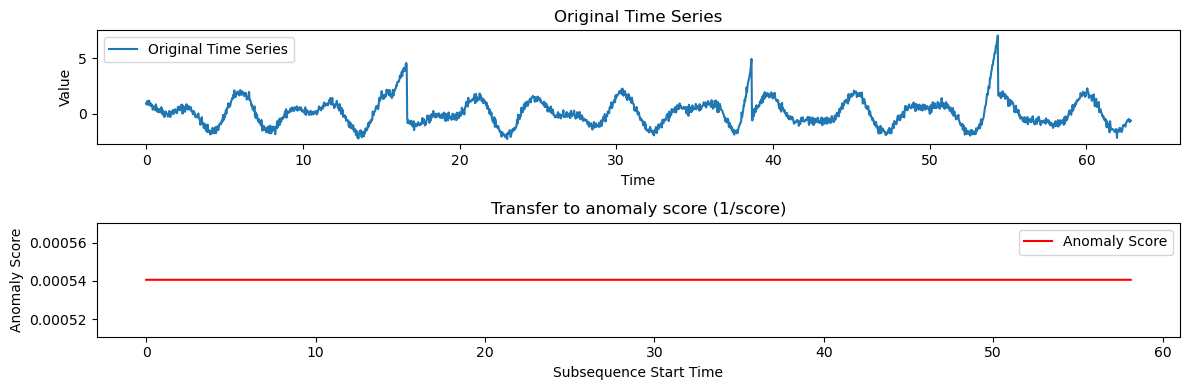

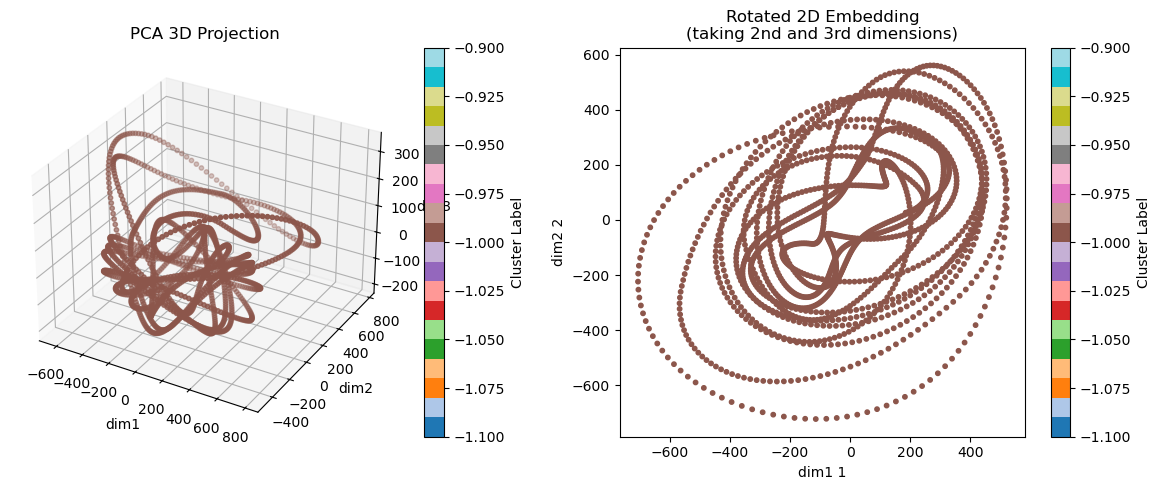

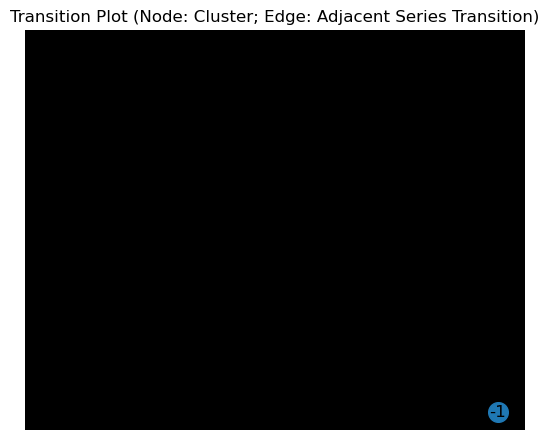

DBSCAN Cluster Label Distribution:
  Label -1: 1851 samples
Anomaly Score: min = 0.000541, max = 0.000541


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from mpl_toolkits.mplot3d import Axes3D  # 用於 3D 繪圖

# ----------------------------
# 1. 模擬複雜時間序列
# ----------------------------
def generate_complex_timeseries(n_points=2000, random_seed=42):
    """
    模擬一條具有非固定週期、複雜形狀的時間序列，
    利用多個正弦波（頻率與幅度隨時間變化）加上隨機噪聲，
    並注入幾個異常區段（突變或異常波形）。
    """
    np.random.seed(random_seed)
    t = np.linspace(0, 20*np.pi, n_points)
    
    # 隨著時間變化的幅度與頻率
    amp1 = 1 + 0.5 * np.sin(0.01 * t)
    freq1 = 1 + 0.3 * np.cos(0.005 * t)
    comp1 = amp1 * np.sin(freq1 * t)
    
    amp2 = 0.8 + 0.3 * np.cos(0.02 * t + 1)
    freq2 = 2 + 0.2 * np.sin(0.007 * t)
    comp2 = amp2 * np.cos(freq2 * t + 0.5)
    
    ts = comp1 + comp2
    
    # 加入隨機噪聲
    noise = 0.2 * np.random.randn(n_points)
    ts += noise
    
    # 注入幾個異常：在特定區段內加入局部突變
    anomaly_indices = [500, 1200, 1700]
    for idx in anomaly_indices:
        ts[idx:idx+30] += np.linspace(0, 5, 30)  # 突然上升
    return t, ts

# ----------------------------
# 2. 子序列提取與局部卷積
# ----------------------------
def extract_subsequences(ts, window_length, conv_size):
    """
    將時間序列 ts 使用滑動視窗提取子序列，並對每個子序列進行局部卷積，
    卷積大小 conv_size (通常設為 window_length/3)
    輸出：
        subsequences: 形狀 (n_subsequences, window_length - conv_size)
    """
    n = len(ts)
    n_subseq = n - window_length + 1
    subsequences = []
    for i in range(n_subseq):
        subseq = ts[i:i+window_length]
        # 局部卷積：對每個位置計算 conv_size 個連續值之和
        conv_features = [np.sum(subseq[j:j+conv_size]) for j in range(window_length - conv_size + 1)]
        # 取前 (window_length - conv_size) 個特徵（與論文公式一致）
        conv_features = conv_features[:window_length - conv_size]
        subsequences.append(conv_features)
    return np.array(subsequences)

# ----------------------------
# 3. PCA 降維至 3D 與旋轉
# ----------------------------
def pca_and_rotate(subseq_matrix, window_length, conv_size, ts):
    """
    對子序列矩陣進行 PCA 降維到 3 維，然後根據常數序列的投影結果計算參考向量，
    再計算旋轉矩陣使得參考向量與 x 軸對齊，並將所有子序列投影旋轉，
    最後返回 2D 嵌入（取旋轉後的第二、第三個維度）以及原始 3D 與旋轉後 3D 結果。
    """
    # PCA 降維到 3D
    pca = PCA(n_components=3)
    proj_3d = pca.fit_transform(subseq_matrix)
    
    # 計算常數序列對應的向量
    # 這裡使用全 min 與全 max 向量，注意：論文中常數子序列通常取定值（例如平均值），這裡做法略有不同
    const_min = np.full((window_length - conv_size,), np.min(ts))
    const_max = np.full((window_length - conv_size,), np.max(ts))
    # 將常數向量轉換到 PCA 空間（reshape 成 1 x d）
    O_min = pca.transform(const_min.reshape(1, -1))[0]
    O_max = pca.transform(const_max.reshape(1, -1))[0]
    # 參考向量：從 O_min 指向 O_max
    v_ref = O_max - O_min
    
    # 計算使 v_ref 對齊到 x 軸 [1, 0, 0] 的旋轉矩陣
    x_axis = np.array([1, 0, 0])
    if np.linalg.norm(v_ref) == 0:
        rotation_matrix = np.eye(3)
    else:
        v_ref_unit = v_ref / np.linalg.norm(v_ref)
        rot_axis = np.cross(v_ref_unit, x_axis)
        norm_axis = np.linalg.norm(rot_axis)
        if norm_axis < 1e-6:
            rotation_matrix = np.eye(3)
        else:
            rot_axis /= norm_axis
            angle = np.arccos(np.clip(np.dot(v_ref_unit, x_axis), -1.0, 1.0))
            K = np.array([[0, -rot_axis[2], rot_axis[1]],
                          [rot_axis[2], 0, -rot_axis[0]],
                          [-rot_axis[1], rot_axis[0], 0]])
            rotation_matrix = np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * (K @ K)
    
    # 將所有 3D 向量進行旋轉
    proj_rotated = (rotation_matrix @ proj_3d.T).T
    # 取第二與第三維作為 2D 嵌入（形狀資訊），軸名稱依原 code 保留
    embedding_2d = proj_rotated[:, 1:3]
    return embedding_2d, proj_3d, proj_rotated, pca

# ----------------------------
# 4. 節點建立與圖結構構造
# ----------------------------
def create_graph_from_clusters(cluster_labels, step=1):
    """
    根據每個子序列的聚類標籤（cluster_labels），利用原始時間序列中子序列之間的相鄰關係，
    建構有向圖。若相鄰兩子序列分別屬於節點 A 與 B，則在圖中增加一條 A->B 的邊，邊權重為轉移次數。
    輸出：networkx.DiGraph 物件
    """
    G = nx.DiGraph()
    n = len(cluster_labels)
    for i in range(n - step):
        src = cluster_labels[i]
        dst = cluster_labels[i + step]
        if G.has_edge(src, dst):
            G[src][dst]['weight'] += 1
        else:
            G.add_edge(src, dst, weight=1)
    return G

def compute_node_degrees(G):
    """
    計算圖中每個節點的度數（考慮入度與出度）
    """
    degrees = {}
    for node in G.nodes():
        deg = G.in_degree(node) + G.out_degree(node)
        degrees[node] = deg
    return degrees

# ----------------------------
# 5. 子序列異常評分
# ----------------------------
def compute_anomaly_scores(cluster_labels, G, degrees, epsilon=1e-6):
    """
    根據圖中每個轉換邊的權重與來源節點的度數，計算每個轉換的正常性得分：
        score = w(edge) * (deg(source) - 1)
    異常分數定義為 1/(score + epsilon)。
    輸出 anomaly_scores: 長度為 (n_subseq - 1)
    """
    anomaly_scores = []
    n = len(cluster_labels)
    for i in range(n - 1):
        src = cluster_labels[i]
        dst = cluster_labels[i+1]
        if G.has_edge(src, dst):
            weight = G[src][dst]['weight']
        else:
            weight = 0
        deg = degrees.get(src, 1)
        score = weight * (deg - 1)
        anomaly_score = 1.0 / (score + epsilon)
        anomaly_scores.append(anomaly_score)
    return np.array(anomaly_scores)

# ----------------------------
# 6. 主流程與視覺化
# ----------------------------
def series2graph_pipeline(ts, window_length=150):
    """
    Series2Graph 整體流程：
      1. 子序列提取與局部卷積（conv_size = window_length/3）
      2. PCA 降維與旋轉，得到 2D 嵌入（以及 3D 結果）
      3. 使用 DBSCAN 聚類建立節點
      4. 建構有向圖（轉移邊）
      5. 根據圖結構計算異常分數
    返回所有中間結果以便視覺化分析。
    """
    conv_size = int(window_length / 3)
    # 1. 子序列提取
    subseq_matrix = extract_subsequences(ts, window_length, conv_size)
    
    # 2. PCA 降維與旋轉
    embedding_2d, proj_3d, proj_rotated, pca_model = pca_and_rotate(subseq_matrix, window_length, conv_size, ts)
    
    # 3. DBSCAN 聚類 (注意：參數 eps 與 min_samples 可能需要根據資料調整，
    #    若結果所有點屬於同一群，則異常分數會固定。)
    dbscan = DBSCAN(eps=0.5, min_samples=10)
    cluster_labels = dbscan.fit_predict(embedding_2d)
    
    # 4. 建構轉移圖
    G = create_graph_from_clusters(cluster_labels)
    degrees = compute_node_degrees(G)
    
    # 5. 計算每個轉移邊的異常分數
    anomaly_scores = compute_anomaly_scores(cluster_labels, G, degrees)
    
    return {
        'subseq_matrix': subseq_matrix,
        'embedding_2d': embedding_2d,
        'cluster_labels': cluster_labels,
        'graph': G,
        'degrees': degrees,
        'anomaly_scores': anomaly_scores,
        'pca_model': pca_model,
        'proj_3d': proj_3d,
        'proj_rotated': proj_rotated
    }

def plot_results(t, ts, results, window_length):
    """
    將原始時間序列、2D 嵌入、聚類結果與異常分數進行視覺化展示：
      (1) 原始時間序列與異常分數曲線
      (2) 同一畫布中左側為 PCA 3D 投影，右側為旋轉後的 2D 嵌入（對應 Fig.2 的兩個視角）
      (3) 簡單展示圖結構（節點大小依據度數，邊粗細依據權重）
    """
    n_subseq = len(results['subseq_matrix'])
    t_subseq = t[:n_subseq]
    
    # (1) 原始時間序列與異常分數（轉換邊，時間點取 t_subseq[:-1]）
    plt.figure(figsize=(12, 4))
    plt.subplot(2,1,1)
    plt.plot(t, ts, label='Original Time Series')
    plt.title("Original Time Series")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    
    plt.subplot(2,1,2)
    plt.plot(t_subseq[:-1], results['anomaly_scores'], color='red', label='Anomaly Score')
    plt.title("Transfer to anomaly score (1/score)")
    plt.xlabel("Subsequence Start Time")
    plt.ylabel("Anomaly Score")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # (2) 同一畫布中展示：左圖為 PCA 3D 投影（使用 proj_3d），右圖為旋轉後 2D 嵌入
    fig = plt.figure(figsize=(12, 5))
    
    # 左側 3D 投影
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    sc1 = ax1.scatter(results['proj_3d'][:, 0], results['proj_3d'][:, 1], results['proj_3d'][:, 2],
                      c=results['cluster_labels'], cmap='tab20', s=10)
    ax1.set_title("PCA 3D Projection")
    ax1.set_xlabel("dim1")
    ax1.set_ylabel("dim2")
    ax1.set_zlabel("dim3")
    fig.colorbar(sc1, ax=ax1, label="Cluster Label")
    
    # 右側 2D 嵌入 (旋轉後取第2、3維，依你原本的軸標示)
    ax2 = fig.add_subplot(1, 2, 2)
    sc2 = ax2.scatter(results['embedding_2d'][:, 0], results['embedding_2d'][:, 1],
                      c=results['cluster_labels'], cmap='tab20', s=10)
    ax2.set_title("Rotated 2D Embedding\n(taking 2nd and 3rd dimensions)")
    ax2.set_xlabel("dim1 1")
    ax2.set_ylabel("dim2 2")
    fig.colorbar(sc2, ax=ax2, label="Cluster Label")
    plt.tight_layout()
    plt.show()
    
    # (3) 圖結構展示：節點大小依據度數，邊粗細依據權重
    plt.figure(figsize=(5,4))
    pos = nx.spring_layout(results['graph'], seed=42)
    node_sizes = [results['degrees'][node]*100 for node in results['graph'].nodes()]
    edge_widths = [results['graph'][u][v]['weight'] for u,v in results['graph'].edges()]
    nx.draw(results['graph'], pos, with_labels=True, node_size=node_sizes, width=edge_widths, arrowsize=20)
    plt.title("Transition Plot (Node: Cluster; Edge: Adjacent Series Transition)")
    plt.show()
    
    # 輸出聚類結果統計與異常分數統計，觀察是否僅出現單一群
    unique, counts = np.unique(results['cluster_labels'], return_counts=True)
    print("DBSCAN Cluster Label Distribution:")
    for u, c in zip(unique, counts):
        print(f"  Label {u}: {c} samples")
    print("Anomaly Score: min = {:.6f}, max = {:.6f}".format(results['anomaly_scores'].min(),
                                                               results['anomaly_scores'].max()))
    # 若 anomaly score 的 min 與 max 差別極小，則表示各轉移的得分幾乎一致（即可能全部屬於同一轉移邊）

# ----------------------------
# 執行主流程
# ----------------------------
if __name__ == "__main__":
    # 產生模擬時間序列
    t, ts = generate_complex_timeseries(n_points=2000)
    
    # 設定子序列視窗長度（例如 150）
    window_length = 150
    
    # 執行 Series2Graph 整體流程
    results = series2graph_pipeline(ts, window_length=window_length)
    
    # 視覺化結果
    plot_results(t, ts, results, window_length)
